<a href="https://colab.research.google.com/github/dhanusharer/Machine-learning-projects/blob/main/pratice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os
import sklearn

In [ ]:
import pandas as pd
import os
file_path="/content/swiggy_cleaned.csv"
if os.path.exists(file_path):
  df=pd.read_csv(file_path)
  print("DataFrame loaded successfully!")
else:
  print(f"File not found at {file_path}")

DataFrame loaded successfully!


In [ ]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance'],
      dtype='object')

In [ ]:
df['distance'].min()

1.4650674052309467

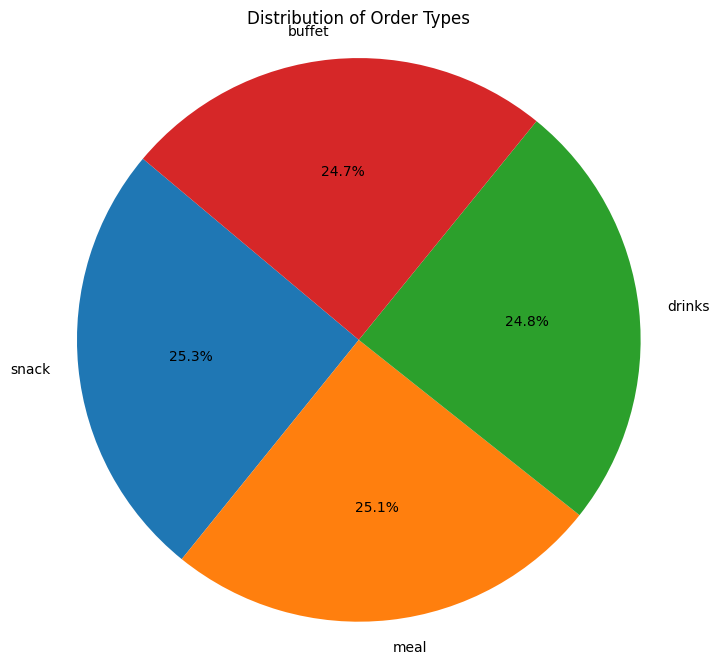

In [ ]:
import matplotlib.pyplot as plt

# Count the occurrences of each order type
order_type_counts = df['type_of_order'].value_counts()

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(order_type_counts, labels=order_type_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Order Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
df['type_of_order'].value_counts()

,count
type_of_order,
snack,11512
meal,11435
drinks,11294
buffet,11261


In [ ]:
df.columns


Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance'],
      dtype='object')

In [ ]:
columns_to_drop=['rider_id','restaurant_latitude','delivery_longitude','delivery_latitude']

In [ ]:
df.isna().sum()

,0
rider_id,0
age,1854
ratings,1908
restaurant_latitude,3630
restaurant_longitude,3630
delivery_latitude,3630
delivery_longitude,3630
order_date,0
weather,525
traffic,510


In [ ]:
columns_to_drop = ['rider_id','restaurant_latitude',
                   'restaurant_longitude','delivery_latitude',
                   'delivery_longitude','order_date','type_of_order','city_type','order_day','order_month',
                   'order_day_of_week','order_time_of_day']

When you run `df.isna().sum()`, the output shows the count of missing (null) values for each column. If a column has a value of `0`, it means there are no missing values in that column.

In [ ]:
# Check for null values in each column
null_values = df.isnull().sum()

# Display columns with null values and their counts
print("Null values per column:")
print(null_values[null_values > 0])

Null values per column:
age                     1854
ratings                 1908
restaurant_latitude     3630
restaurant_longitude    3630
delivery_latitude       3630
delivery_longitude      3630
weather                  525
traffic                  510
multiple_deliveries      993
festival                 228
city_type               1198
pickup_time_minutes     1640
order_time_hour         1640
distance                3630
dtype: int64


In [ ]:
df.drop(columns=columns_to_drop, inplace=True)
print("Columns dropped successfully!")

Columns dropped successfully!


In [ ]:
df.dropna(inplace=True)

<Axes: >

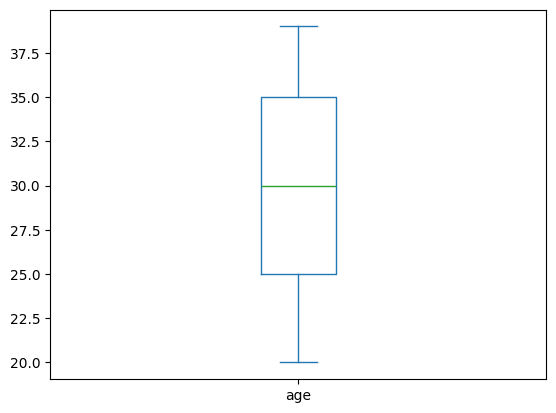

In [ ]:
df['age'].plot(kind='box')

<Axes: >

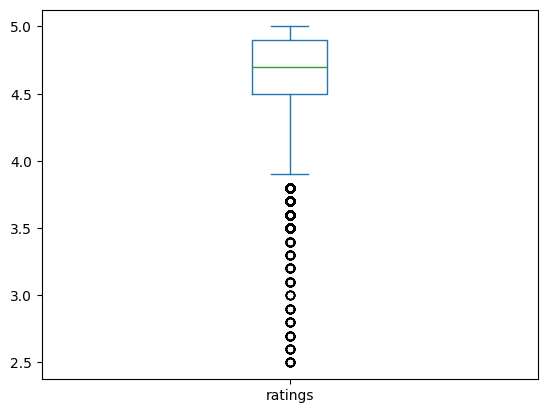

In [ ]:
df['ratings'].plot(kind='box')

<Axes: >

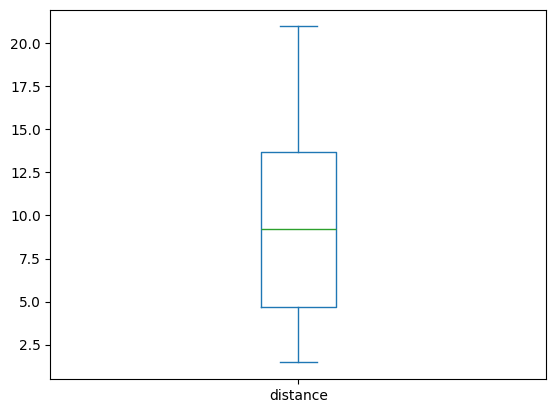

In [ ]:
df['distance'].plot(kind='box')

In [ ]:
Nominal_cols = ['type_of_vehicle','festival','city_name','is_weekend']
Ordinal_cols = ['weather','traffic']
Numerical_cols = ['age','ratings','vehicle_condition','multiple_deliveries','pickup_time_minutes','order_time_hour','distance']


Let's categorize the columns into nominal, ordinal, and numerical types.

*   **Nominal Data:** Categories without a natural order (e.g., city names, types of order).
*   **Ordinal Data:** Categories with a natural order (e.g., ratings on a scale, traffic levels).
*   **Numerical Data:** Quantitative values (e.g., age, distance, time taken).

In [ ]:
order_ = [['sunny','cloudy','fog','windy','sandstorms','stormy'],['low','medium','high','jam']]

In [ ]:
print("DataFrame columns and their data types:")
print(df.dtypes)

# Based on column names and common interpretations, here's a possible segregation:

nominal_cols = ['weather', 'traffic', 'vehicle_condition', 'type_of_vehicle', 'multiple_deliveries', 'festival', 'city_name', 'is_weekend', 'order_time_of_day']
ordinal_cols = ['ratings'] # Assuming ratings have an inherent order/scale
numerical_cols = ['age', 'time_taken', 'pickup_time_minutes', 'order_time_hour', 'distance'] # Columns with numerical values

print("\nPossible Nominal Columns:", nominal_cols)
print("Possible Ordinal Columns:", ordinal_cols)
print("Possible Numerical Columns:", numerical_cols)

# Note: You may need to adjust this classification based on a deeper understanding of the data.

DataFrame columns and their data types:
age                    float64
ratings                float64
weather                 object
traffic                 object
vehicle_condition        int64
type_of_vehicle         object
multiple_deliveries    float64
festival                object
time_taken               int64
city_name               object
is_weekend               int64
pickup_time_minutes    float64
order_time_hour        float64
distance               float64
dtype: object

Possible Nominal Columns: ['weather', 'traffic', 'vehicle_condition', 'type_of_vehicle', 'multiple_deliveries', 'festival', 'city_name', 'is_weekend', 'order_time_of_day']
Possible Ordinal Columns: ['ratings']
Possible Numerical Columns: ['age', 'time_taken', 'pickup_time_minutes', 'order_time_hour', 'distance']


In [ ]:
from sklearn.compose  import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
Transformer = ColumnTransformer([('One Hot Encoding',OneHotEncoder(),Nominal_cols),
                  ('Ordinal Encoding',OrdinalEncoder(categories=order_),Ordinal_cols),
                  ("Feature Scaling",StandardScaler(),Numerical_cols)])

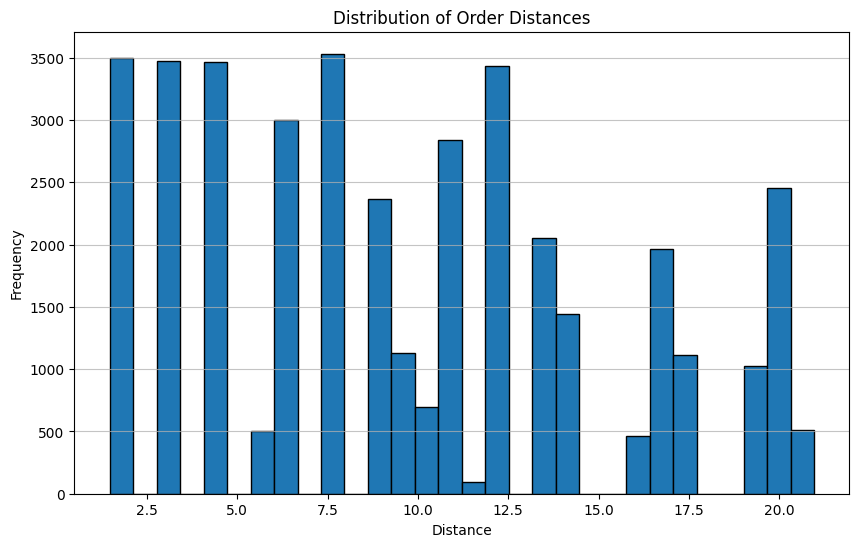

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['distance'], bins=30, edgecolor='black') # You can adjust the number of bins
plt.title('Distribution of Order Distances')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
Transformer


ColumnTransformer(transformers=[('One Hot Encoding', OneHotEncoder(),
                                 ['type_of_vehicle', 'festival', 'city_name',
                                  'is_weekend']),
                                ('Ordinal Encoding',
                                 OrdinalEncoder(categories=[['sunny', 'cloudy',
                                                             'fog', 'windy',
                                                             'sandstorms',
                                                             'stormy'],
                                                            ['low', 'medium',
                                                             'high', 'jam']]),
                                 ['weather', 'traffic']),
                                ('Feature Scaling', StandardScaler(),
                                 ['age', 'ratings', 'vehicle_condition',
                                  'multiple_deliveries', 'pickup_time_minutes',
                                  'order_time_hour', 'distance'])])

In [ ]:
df.shape

(39068, 14)

In [ ]:
max_distance = df['distance'].max()
print(f"The maximum distance of an order is: {max_distance}")

The maximum distance of an order is: 20.969489380087342


In [ ]:
df.info

<bound method DataFrame.info of         age  ratings     weather traffic  vehicle_condition type_of_vehicle  \
0      37.0      4.9       sunny    high                  2      motorcycle   
1      34.0      4.5      stormy     jam                  2         scooter   
2      23.0      4.4  sandstorms     low                  0      motorcycle   
3      38.0      4.7       sunny  medium                  0      motorcycle   
4      32.0      4.6      cloudy    high                  1         scooter   
...     ...      ...         ...     ...                ...             ...   
45496  35.0      4.2       windy     jam                  2      motorcycle   
45497  30.0      4.8       windy    high                  1      motorcycle   
45499  30.0      4.9      cloudy     low                  1         scooter   
45500  20.0      4.7      cloudy    high                  0      motorcycle   
45501  23.0      4.9         fog  medium                  2         scooter   

       multiple_deliveries festival  time_taken city_name  is_weekend  \
0                      0.0       no          24      INDO           1   
1                      1.0       no          33      BANG           0   
2                      1.0       no          26      BANG           1   
3                      1.0       no          21     COIMB           0   
4                      1.0       no          30      CHEN           1   
...                    ...      ...         ...       ...         ...   
45496                  1.0       no          33    RANCHI           0   
45497                  0.0       no          32       JAP           0   
45499                  0.0       no          16      CHEN           0   
45500                  1.0       no          26     COIMB           0   
45501                  1.0       no          36    RANCHI           0   

       pickup_time_minutes  order_time_hour   distance  
0                     15.0             11.0   3.025149  
1                      5.0             19.0  20.183530  
2                     15.0              8.0   1.552758  
3                     10.0             18.0   7.790401  
4                     15.0             13.0   6.210138  
...                    ...              ...        ...  
45496                 10.0             21.0  16.600272  
45497                 10.0             11.0   1.489846  
45499                 15.0             23.0   4.657195  
45500                  5.0             13.0   6.232393  
45501                  5.0             17.0  12.074396  

[39068 rows x 14 columns]>

In [ ]:
#Linear Regression
from sklearn.linear_model import LinearRegression

In [ ]:
X = df.drop('time_taken',axis = 1)
y = df['time_taken']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=24)

In [ ]:
X_train.shape


(31254, 13)

In [ ]:
X_train

,age,ratings,weather,traffic,vehicle_condition,type_of_vehicle,multiple_deliveries,festival,city_name,is_weekend,pickup_time_minutes,order_time_hour,distance
4145,39.0,4.9,stormy,low,1,scooter,1.0,no,HYD,0,15.0,22.0,12.292600
27214,24.0,4.9,sunny,low,1,scooter,1.0,no,HYD,0,5.0,22.0,19.974200
44548,29.0,4.6,fog,jam,0,motorcycle,1.0,no,COIMB,0,5.0,19.0,12.463888
16866,20.0,4.7,fog,low,0,motorcycle,1.0,no,DEH,0,15.0,22.0,19.088794
38924,27.0,4.6,stormy,medium,2,electric_scooter,0.0,no,MYS,0,15.0,17.0,10.881731
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7589,36.0,4.8,cloudy,medium,1,scooter,1.0,no,PUNE,0,15.0,18.0,12.257620
25101,34.0,5.0,fog,high,2,motorcycle,1.0,no,BHP,0,5.0,11.0,1.510098
23020,28.0,4.9,sunny,low,2,motorcycle,1.0,no,VAD,1,10.0,10.0,1.514787
16876,39.0,4.5,cloudy,jam,1,scooter,1.0,no,COIMB,1,15.0,19.0,9.348449


In [ ]:
y_train.shape

(31254,)

In [ ]:
X_test.shape

(7814, 13)

In [ ]:
y_test.shape

(7814,)

In [ ]:
Model_lr = Pipeline([('Data preprocessing',Transformer),
         ("Linear Regression",LinearRegression())])
Model_lr

Pipeline(steps=[('Data preprocessing',
                 ColumnTransformer(transformers=[('One Hot Encoding',
                                                  OneHotEncoder(),
                                                  ['type_of_vehicle',
                                                   'festival', 'city_name',
                                                   'is_weekend']),
                                                 ('Ordinal Encoding',
                                                  OrdinalEncoder(categories=[['sunny',
                                                                              'cloudy',
                                                                              'fog',
                                                                              'windy',
                                                                              'sandstorms',
                                                                              'stormy'],
                                                                             ['low',
                                                                              'medium',
                                                                              'high',
                                                                              'jam']]),
                                                  ['weather', 'traffic']),
                                                 ('Feature Scaling',
                                                  StandardScaler(),
                                                  ['age', 'ratings',
                                                   'vehicle_condition',
                                                   'multiple_deliveries',
                                                   'pickup_time_minutes',
                                                   'order_time_hour',
                                                   'distance'])])),
                ('Linear Regression', LinearRegression())])

In [ ]:
from  sklearn.metrics import r2_score,mean_squared_error

In [ ]:
Model_lr.fit(X_train,y_train)
y_pred = Model_lr.predict(X_test)
print("MSE",mean_squared_error(y_test,y_pred))
print("r2 Score",r2_score(y_test,y_pred))

MSE 42.376399928848016
r2 Score 0.5182913344671108


In [ ]:
#KNN Regression
from sklearn.neighbors import KNeighborsRegressor
Model_knn = Pipeline([('Data preprocessing',Transformer),
         ("KNN",KNeighborsRegressor())])
Model_knn.fit(X_train,y_train)
y_pred = Model_knn.predict(X_test)
print("MSE",mean_squared_error(y_test,y_pred))
print("r2 Score",r2_score(y_test,y_pred))

MSE 27.10050678269772
r2 Score 0.6919382255340818


In [ ]:
#SupportVector Machine
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
Model_svr = Pipeline([('Data preprocessing',Transformer),
         ("Support Vector Machine",SVR())])
Model_svr.fit(X_train,y_train)
y_pred = Model_svr.predict(X_test)
print("MSE",mean_squared_error(y_test,y_pred))
print("r2 Score",r2_score(y_test,y_pred))

MSE 27.568576874988214
r2 Score 0.6866174946576579


In [ ]:
#Decision Tree
from sklearn.tree import DecisionTreeRegressor
Model_dt = Pipeline([('Data preprocessing',Transformer),
         ("Decision Tree",DecisionTreeRegressor())])
Model_dt.fit(X_train,y_train)
y_pred = Model_dt.predict(X_test)
print("MSE",mean_squared_error(y_test,y_pred))
print("r2 Score",r2_score(y_test,y_pred))

MSE 27.83145636037881
r2 Score 0.6836292435009741


In [ ]:
#Xgboost
from xgboost import XGBRegressor,XGBRFRegressor
Model_xgb = Pipeline([('Data preprocessing',Transformer),
         ("Linear Regression",XGBRFRegressor())])
Model_xgb.fit(X_train,y_train)
y_pred = Model_xgb.predict(X_test)
print("MSE",mean_squared_error(y_test,y_pred))
print("r2 Score",r2_score(y_test,y_pred))

MSE 26.13079071044922
r2 Score 0.7029613256454468


In [ ]:
import pickle

In [ ]:
with open(r'D:\Deployement\model.pkl','wb') as file:
    pickle.dump(Model_xgb,file)

In [ ]:
X.dtypes

,0
age,float64
ratings,float64
weather,object
traffic,object
vehicle_condition,int64
type_of_vehicle,object
multiple_deliveries,float64
festival,object
city_name,object
is_weekend,int64


In [ ]:
df['city_name'].unique()

array(['INDO', 'BANG', 'COIMB', 'CHEN', 'HYD', 'RANCHI', 'MYS', 'DEH',
       'KOC', 'PUNE', 'LUDH', 'KNP', 'MUM', 'KOL', 'JAP', 'SUR', 'GOA',
       'AGR', 'ALH', 'VAD', 'AURG', 'BHP'], dtype=object)

In [ ]:
df.columns

Index(['age', 'ratings', 'weather', 'traffic', 'vehicle_condition',
       'type_of_vehicle', 'multiple_deliveries', 'festival', 'time_taken',
       'city_name', 'is_weekend', 'pickup_time_minutes', 'order_time_hour',
       'distance'],
      dtype='object')

In [ ]:
df.columns

Index(['age', 'ratings', 'weather', 'traffic', 'vehicle_condition',
       'type_of_vehicle', 'multiple_deliveries', 'festival', 'time_taken',
       'city_name', 'is_weekend', 'pickup_time_minutes', 'order_time_hour',
       'distance'],
      dtype='object')

In [ ]:
df.columns